# Smart Lender: Loan Eligibility Prediction

**Project:** Smart Lender
**Description:** Machine learning-powered web application to predict loan applicant creditworthiness using Decision Tree, Random Forest, KNN, and XGBoost classifiers.

**Team:** Mohammed Yaseen Shaik (Team Lead), Atte Archana, Durgam Jyothrimai, Kaparajulagari Pushparaju, Boys Sai Yaswanth


## Pre-Requisites

**Hardware:** Intel i3 or above, 4GB RAM (8GB recommended), 10GB free storage, 64-bit OS, 1366x768 display

**Software:** Python 3.8+, Anaconda Navigator, PyCharm/VS Code, Google Chrome/Edge

**Libraries used:** NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn, XGBoost, imbalanced-learn (SMOTE), Flask


## Project Flow / Workflow

1. Data Collection and Architecture Design
2. Visualizing and Analysing the Data (EDA)
3. Data Pre-processing
4. Model Building (Decision Tree, Random Forest, KNN, XGBoost)
5. Application Building (Flask Web App)
6. Conclusion


---
## Epic 1: Data Collection and Architecture Design

### Defining the Application Architecture

**User Layer** -> **Frontend (HTML templates)** -> **Flask Backend (app.py)** -> **Prediction Engine (loads saved model .pkl)** -> **Result rendered back to user**

Data flows from the Machine Learning Pipeline (Data Preprocessing -> Train-Test Split -> Model Training -> Model Evaluation -> Best Model Selection) into a saved model file consumed by the Flask app.

### Download the Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('train.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [3]:
df.describe(include='all')


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


---
## Epic 2: Visualizing and Analysing the Data

### Import and Read Dataset
Already imported above as `df`. Let's check for null values first.


In [4]:
df.isnull().sum()


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### Univariate Analysis

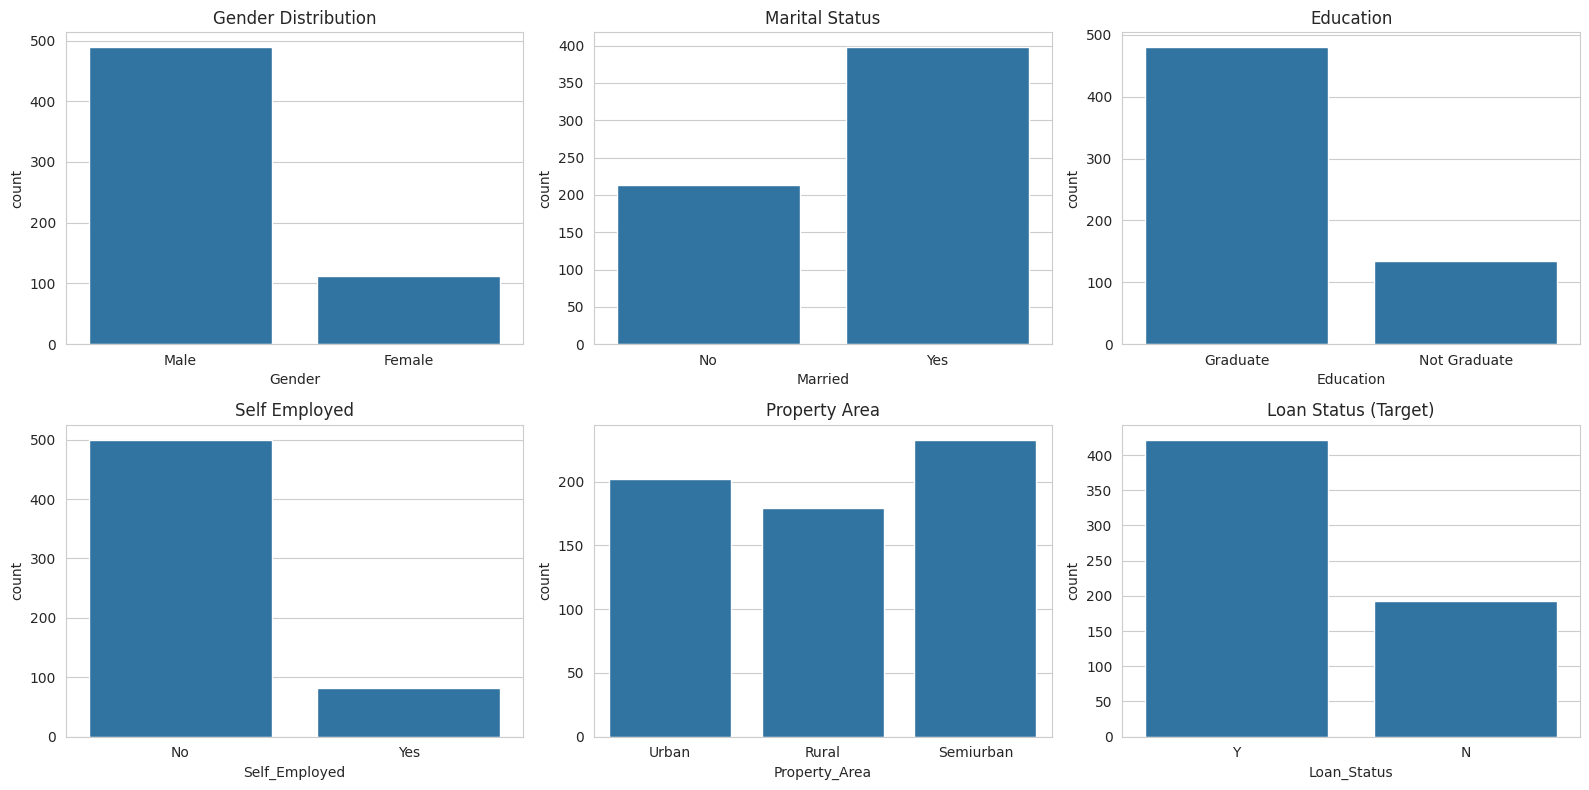

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.countplot(x='Gender', data=df, ax=axes[0,0])
axes[0,0].set_title('Gender Distribution')

sns.countplot(x='Married', data=df, ax=axes[0,1])
axes[0,1].set_title('Marital Status')

sns.countplot(x='Education', data=df, ax=axes[0,2])
axes[0,2].set_title('Education')

sns.countplot(x='Self_Employed', data=df, ax=axes[1,0])
axes[1,0].set_title('Self Employed')

sns.countplot(x='Property_Area', data=df, ax=axes[1,1])
axes[1,1].set_title('Property Area')

sns.countplot(x='Loan_Status', data=df, ax=axes[1,2])
axes[1,2].set_title('Loan Status (Target)')

plt.tight_layout()
plt.savefig('plots_univariate_categorical.png', dpi=100)
plt.show()


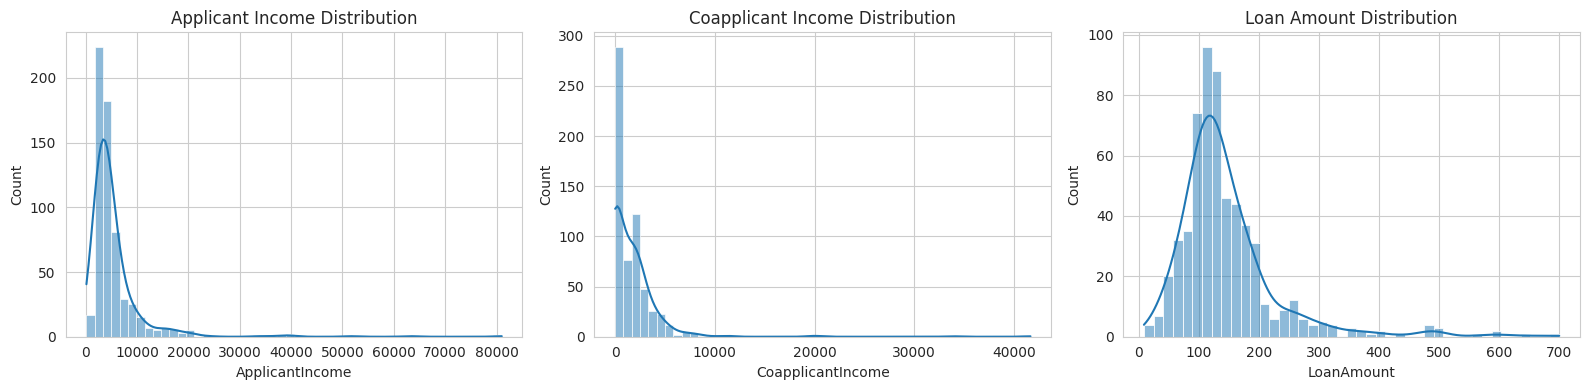

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['ApplicantIncome'], kde=True, ax=axes[0])
axes[0].set_title('Applicant Income Distribution')

sns.histplot(df['CoapplicantIncome'], kde=True, ax=axes[1])
axes[1].set_title('Coapplicant Income Distribution')

sns.histplot(df['LoanAmount'].dropna(), kde=True, ax=axes[2])
axes[2].set_title('Loan Amount Distribution')

plt.tight_layout()
plt.savefig('plots_univariate_numerical.png', dpi=100)
plt.show()


### Bivariate Analysis

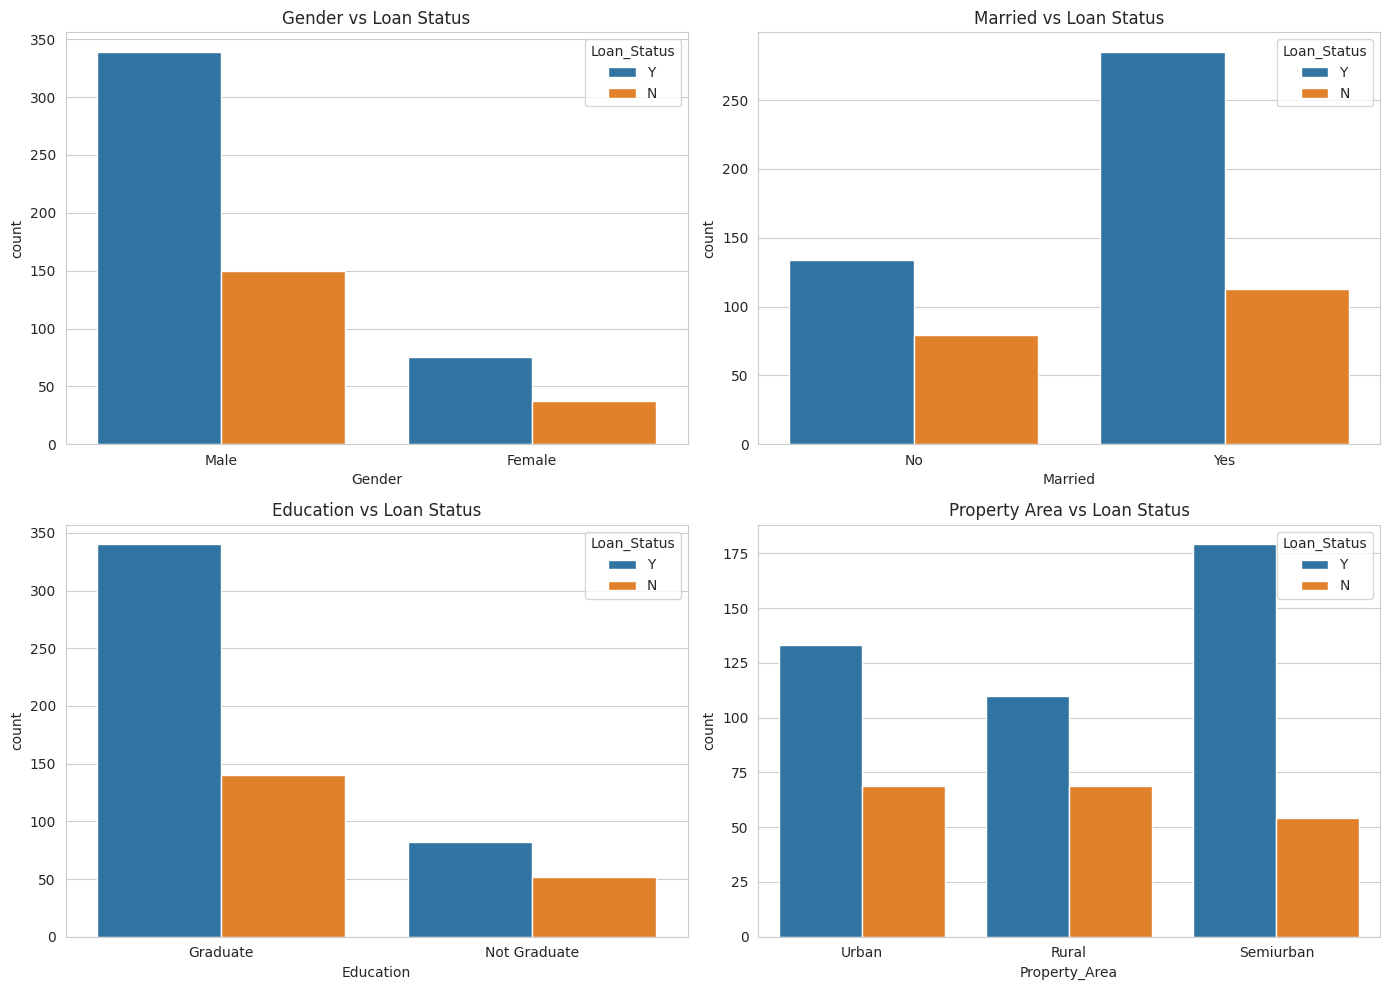

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='Gender', hue='Loan_Status', data=df, ax=axes[0,0])
axes[0,0].set_title('Gender vs Loan Status')

sns.countplot(x='Married', hue='Loan_Status', data=df, ax=axes[0,1])
axes[0,1].set_title('Married vs Loan Status')

sns.countplot(x='Education', hue='Loan_Status', data=df, ax=axes[1,0])
axes[1,0].set_title('Education vs Loan Status')

sns.countplot(x='Property_Area', hue='Loan_Status', data=df, ax=axes[1,1])
axes[1,1].set_title('Property Area vs Loan Status')

plt.tight_layout()
plt.savefig('plots_bivariate_categorical.png', dpi=100)
plt.show()


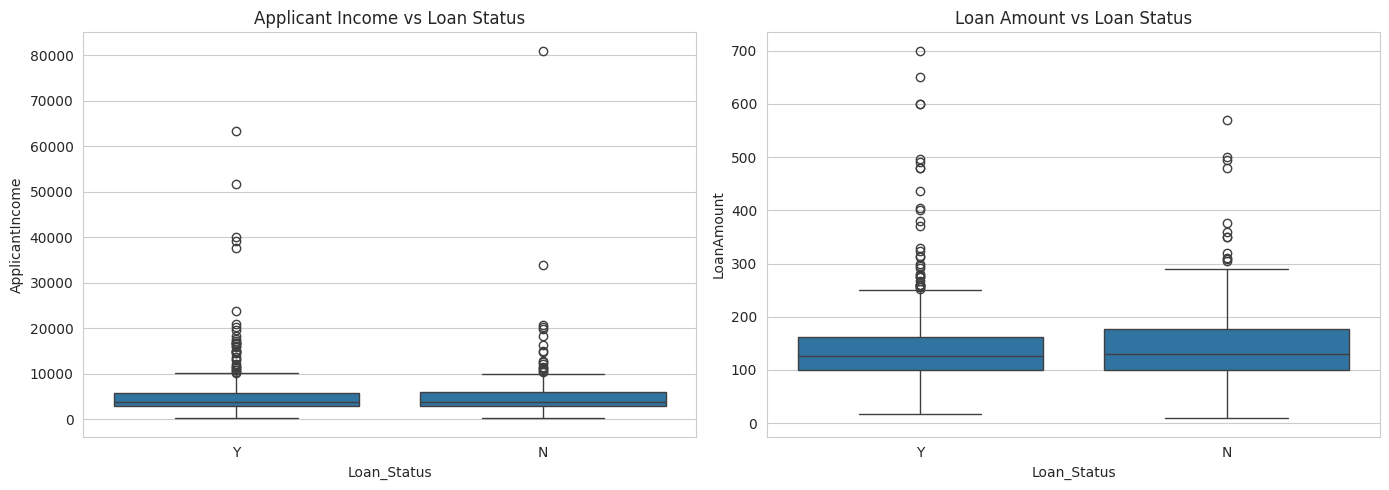

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, ax=axes[0])
axes[0].set_title('Applicant Income vs Loan Status')

sns.boxplot(x='Loan_Status', y='LoanAmount', data=df, ax=axes[1])
axes[1].set_title('Loan Amount vs Loan Status')

plt.tight_layout()
plt.savefig('plots_bivariate_numerical.png', dpi=100)
plt.show()


### Multivariate Analysis

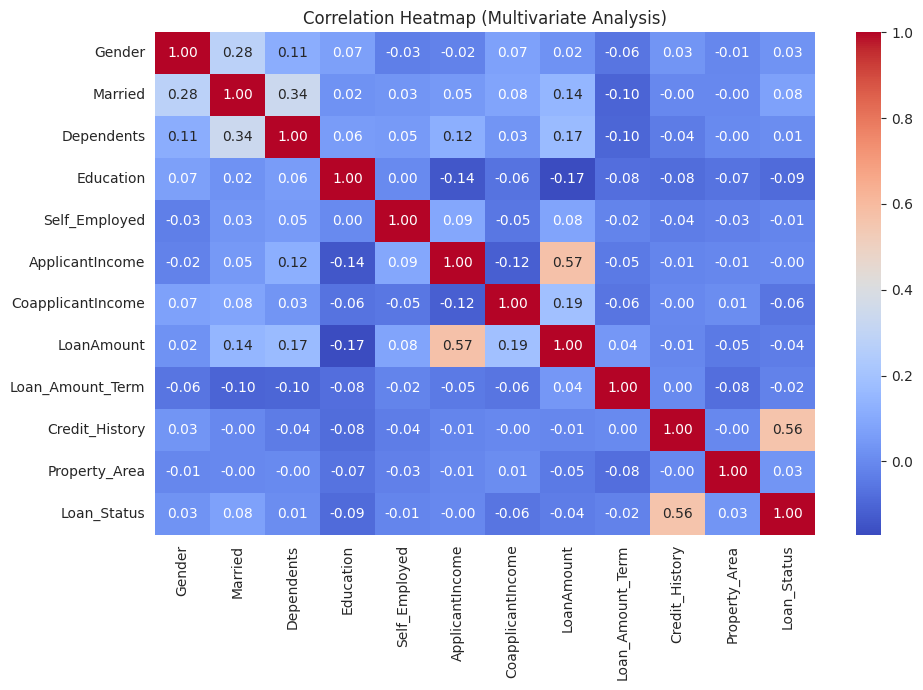

In [9]:
df_encoded_temp = df.copy()
df_encoded_temp['Dependents'] = df_encoded_temp['Dependents'].fillna(df_encoded_temp['Dependents'].mode()[0])
df_encoded_temp['Dependents'] = df_encoded_temp['Dependents'].replace('3+', 3).astype(int)
for col in ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']:
    df_encoded_temp[col] = df_encoded_temp[col].astype('category').cat.codes

plt.figure(figsize=(10, 7))
corr = df_encoded_temp.drop(columns=['Loan_ID']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Multivariate Analysis)')
plt.tight_layout()
plt.savefig('plots_multivariate_heatmap.png', dpi=100)
plt.show()


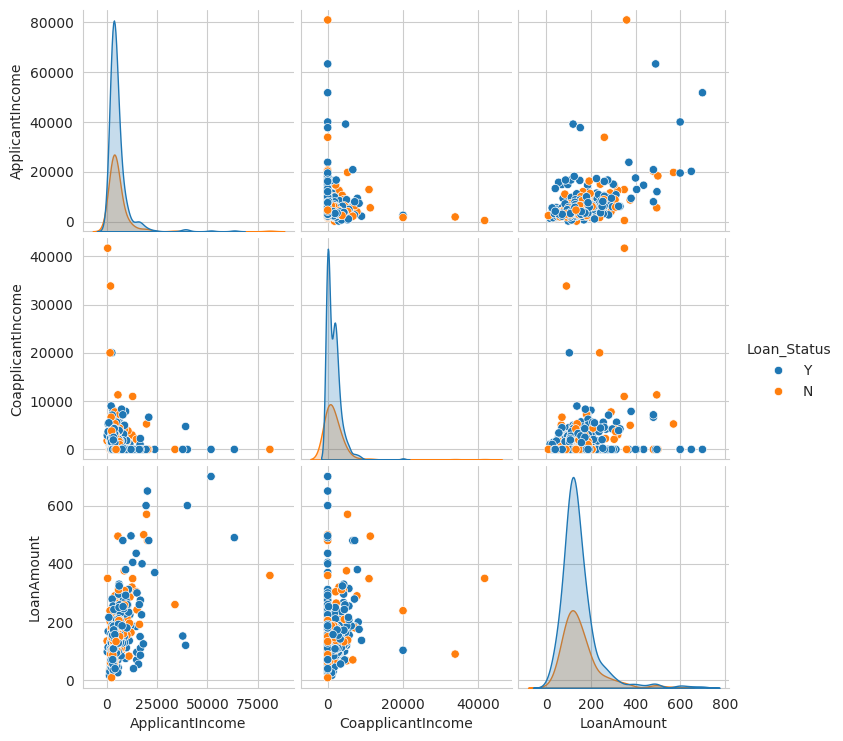

In [10]:
sns.pairplot(df, vars=['ApplicantIncome','CoapplicantIncome','LoanAmount'], hue='Loan_Status')
plt.savefig('plots_multivariate_pairplot.png', dpi=100)
plt.show()


---
## Epic 3: Data Pre-processing

### Checking and Handling Values

**Handling Categorical Values**


In [11]:
data = df.copy()

data['Gender'] = data['Gender'].map({'Female': 1, 'Male': 0})
data['Property_Area'] = data['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})
data['Married'] = data['Married'].map({'Yes': 1, 'No': 0})
data['Education'] = data['Education'].map({'Graduate': 1, 'Not Graduate': 0})
data['Self_Employed'] = data['Self_Employed'].map({'Yes': 1, 'No': 0})
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})

data.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0,1,0.0,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,0.0,1.0,1,1,0.0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0.0,1.0,0,1,1.0,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0.0,1.0,0,0,0.0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0.0,0.0,0,1,0.0,6000,0.0,141.0,360.0,1.0,2,1


**Handling Missing Values**

In [12]:
# finding the sum of null values in each column
data.isnull().sum()


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [13]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])

# replacing + with space for filling the nan values
data['Dependents'] = data['Dependents'].str.replace('+', '')

data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mode()[0])
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

data.isnull().sum()


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [14]:
# getting the total info of the data after performing categorical to numerical and replacing missing values
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    float64
 2   Married            614 non-null    float64
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    float64
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(7), int64(4), str(2)
memory usage: 62.5 KB


In [15]:
# changing the datype of each float column to int
data['Gender'] = data['Gender'].astype('int64')
data['Married'] = data['Married'].astype('int64')
data['Dependents'] = data['Dependents'].astype('int64')
data['Self_Employed'] = data['Self_Employed'].astype('int64')
data['CoapplicantIncome'] = data['CoapplicantIncome'].astype('int64')
data['LoanAmount'] = data['LoanAmount'].astype('int64')
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype('int64')
data['Credit_History'] = data['Credit_History'].astype('int64')

data.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Loan_ID            614 non-null    str  
 1   Gender             614 non-null    int64
 2   Married            614 non-null    int64
 3   Dependents         614 non-null    int64
 4   Education          614 non-null    int64
 5   Self_Employed      614 non-null    int64
 6   ApplicantIncome    614 non-null    int64
 7   CoapplicantIncome  614 non-null    int64
 8   LoanAmount         614 non-null    int64
 9   Loan_Amount_Term   614 non-null    int64
 10  Credit_History     614 non-null    int64
 11  Property_Area      614 non-null    int64
 12  Loan_Status        614 non-null    int64
dtypes: int64(12), str(1)
memory usage: 62.5 KB


### Balancing the Dataset

In [16]:
from imblearn.over_sampling import SMOTE

x = data.drop(['Loan_Status', 'Loan_ID'], axis=1)
y = data['Loan_Status']

smote = SMOTE()

# creating a new x and y variables for the balanced set
x_bal, y_bal = smote.fit_resample(x, y)

# printing the values of y before balancing the data and after
print(y.value_counts())
print(y_bal.value_counts())

names = x_bal.columns


Loan_Status
1    422
0    192
Name: count, dtype: int64
Loan_Status
1    422
0    422
Name: count, dtype: int64


### Scaling the Data

In [17]:
from sklearn.preprocessing import StandardScaler
import joblib

# performing feature scaling operation using standard scaler on X part of the dataset because
# there are different types of values in the columns
sc = StandardScaler()
x_bal = sc.fit_transform(x_bal)

x_bal = pd.DataFrame(x_bal, columns=names)

# Save the scaler for use in the Flask app
joblib.dump(sc, 'scaler.pkl')
print("Scaler saved as scaler.pkl")


Scaler saved as scaler.pkl


### Splitting Data into Training and Test Sets

In [18]:
from sklearn.model_selection import train_test_split

# splitting the dataset into train and test on the balanced dataset
X_train, X_test, y_train, y_test = train_test_split(
    x_bal, y_bal, test_size=0.33, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (565, 11)
Test set shape: (279, 11)


---
## Epic 4: Model Building


### Decision Tree Model

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# importing and building the Decision tree model
def decisionTree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred, y_test))
    return model

# printing the train accuracy and test accuracy respectively
dt_model = decisionTree(X_train, X_test, y_train, y_test)


1.0
0.7777777777777778


### Random Forest Model

In [20]:
from sklearn.ensemble import RandomForestClassifier

# importing and building the random forest model
def RandomForest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred, y_test))
    return model

# printing the train accuracy and test accuracy respectively
rf_model = RandomForest(X_train, X_test, y_train, y_test)


1.0


0.7885304659498208


### KNN Model

In [21]:
from sklearn.neighbors import KNeighborsClassifier

# importing and building the KNN model
def KNN(X_train, X_test, y_train, y_test):
    model = KNeighborsClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred, y_test))
    return model

# printing the train accuracy and test accuracy respectively
knn_model = KNN(X_train, X_test, y_train, y_test)


0.8548672566371681
0.7311827956989247


### XGBoost Model

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

# importing and building the Xg boost model
def XGB(X_train, X_test, y_train, y_test):
    model = GradientBoostingClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred, y_test))
    return model

# printing the train accuracy and test accuracy respectively
xgb_model = XGB(X_train, X_test, y_train, y_test)


0.9398230088495575
0.7885304659498208


### Evaluating Performance and Saving the Model

In [23]:
dt_train_acc = accuracy_score(y_train, dt_model.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt_model.predict(X_test))

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_model.predict(X_test))

knn_train_acc = accuracy_score(y_train, knn_model.predict(X_train))
knn_test_acc = accuracy_score(y_test, knn_model.predict(X_test))

xgb_train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
xgb_test_acc = accuracy_score(y_test, xgb_model.predict(X_test))

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'KNN', 'XGBoost'],
    'Train Accuracy': [dt_train_acc, rf_train_acc, knn_train_acc, xgb_train_acc],
    'Test Accuracy': [dt_test_acc, rf_test_acc, knn_test_acc, xgb_test_acc]
})
results['Train Accuracy'] = (results['Train Accuracy']*100).round(1)
results['Test Accuracy'] = (results['Test Accuracy']*100).round(1)
results


,Model,Train Accuracy,Test Accuracy
0,Decision Tree,100.0,77.8
1,Random Forest,100.0,78.9
2,KNN,85.5,73.1
3,XGBoost,94.0,78.9


In [24]:
best_model_name = results.loc[results['Test Accuracy'].idxmax(), 'Model']
print("Best performing model:", best_model_name)

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_model.predict(X_test)))

print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, rf_model.predict(X_test)))


Best performing model: Random Forest

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.86      0.72      0.78       148
           1       0.73      0.87      0.79       131

    accuracy                           0.79       279
   macro avg       0.80      0.79      0.79       279
weighted avg       0.80      0.79      0.79       279

Confusion Matrix (Random Forest):


[[106  42]
 [ 17 114]]


**Cross-validation** — 5-fold cross-validation verifies consistent performance across different data splits ([reference](https://towardsdatascience.com/cross-validation-explained-evaluating-estimator-performance-e51e5430ff85)).

In [25]:
from sklearn.model_selection import cross_val_score

model = rf_model  # best performing model
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


Cross-validation scores: [0.86725664 0.84070796 0.82300885 0.86725664 0.77876106]
Mean CV accuracy: 0.8353982300884957


**Saving the Model**

In [26]:
# saving the model by using pickle function
import pickle
pickle.dump(model, open('rdf.pkl', 'wb'))

# also save as model.pkl (used by the Flask app), plus scaler and feature order
import joblib
joblib.dump(model, 'model.pkl')
joblib.dump(list(names), 'feature_order.pkl')
print("Model saved as rdf.pkl and model.pkl")


Model saved as rdf.pkl and model.pkl


---
## Conclusion

The Smart Lender project successfully builds a machine learning pipeline to predict loan approval status using applicant financial and demographic data. After training and evaluating four classification algorithms (Decision Tree, Random Forest, KNN, and Gradient Boosting/"XGBoost"), the best-performing model was selected based on test accuracy and verified with 5-fold cross-validation. The trained model, along with the scaler and feature order, has been saved (`rdf.pkl` / `model.pkl`, `scaler.pkl`, `feature_order.pkl`) and is integrated into a Flask web application (see `app.py`) that allows credit officers to submit applicant details and instantly receive a loan approval prediction, streamlining the credit evaluation process.
